In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib import cm
from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable
from collections import defaultdict
from mapclassify import Quantiles

block_ids      = np.load("data/block_ids.npy",      allow_pickle=True)
blocks_in_data = np.load("data/blocks_in_data.npy", allow_pickle=True)
nodes_data = np.loadtxt("data/szu_coordinates_nodes.csv", delimiter=",",  skiprows=1)
edges_data = np.loadtxt("data/szu_coordinates_edges.csv", delimiter=",",  skiprows=1)
stations_data_coordinates = np.genfromtxt(
    "data/szu_station_coordinates.csv", delimiter=";", skip_header=1, dtype=str)
try:
    stations_data = np.genfromtxt(
        "data/szu_stations.csv", delimiter=";", dtype=str, skip_header=1)
except Exception:
    df = pd.read_csv("data/szu_stations.csv", encoding="latin1", delimiter=";")
    stations_data = df.to_numpy()


In [2]:
nodes_ids = nodes_data[:, 0]; nodes_x = nodes_data[:, 1]; nodes_y = nodes_data[:, 2]
edges_source = edges_data[:, 0]; edges_target = edges_data[:, 1]
station_names  = stations_data_coordinates[:, 0]
station_coords = stations_data_coordinates[:, 1:].astype(float)


In [3]:
spatial_series = np.load("../simdata/heatmap/taurangethroaway_second_10.npy", allow_pickle=True)

# shape: (n_runs=10, n_taus=1, n_blocks=507, n_time)
runs_cumsums = np.cumsum(np.maximum(spatial_series[:, 0, :, :], 0), axis=2)
mean_data = np.mean(runs_cumsums, axis=0)  # (n_blocks, n_time)
std_data  = np.std(runs_cumsums,  axis=0)  # (n_blocks, n_time)

T = mean_data.shape[1]
firstthird     = int(1.5  * T / 40)   # ~08:00 snapshot
secondthids    = int(6.5  * T / 40)   # ~10:00 snapshot
lasteventthird = int(10.5 * T / 40)   # ~12:00 snapshot
print(f"time slices: {firstthird}, {secondthids}, {lasteventthird}  (T={T})")
print(f"runs: {runs_cumsums.shape[0]}, std nonzero: {(std_data > 0).sum()}")


time slices: 1497, 6491, 10485  (T=39946)
runs: 10, std nonzero: 13557431


In [4]:
_unique_net = np.unique(blocks_in_data)
block_map_reverse = {int(i): int(b) for i, b in enumerate(_unique_net)}

block_id_mean_V_data             = {}
block_id_mean_V_data_firstthird  = {}
block_id_mean_V_data_secondthird = {}
block_id_std_V_data              = {}
block_id_std_V_data_firstthird   = {}
block_id_std_V_data_secondthird  = {}
for ub in np.unique(block_ids):
    key = block_map_reverse[int(ub)]
    block_id_mean_V_data[key]             = mean_data[ub, lasteventthird]
    block_id_mean_V_data_firstthird[key]  = mean_data[ub, firstthird]
    block_id_mean_V_data_secondthird[key] = mean_data[ub, secondthids]
    block_id_std_V_data[key]              = std_data[ub, lasteventthird]
    block_id_std_V_data_firstthird[key]   = std_data[ub, firstthird]
    block_id_std_V_data_secondthird[key]  = std_data[ub, secondthids]


In [5]:
blocks_in_data = np.load("data/blocks_in_data.npy", allow_pickle=True)

unique_blocks = np.unique(blocks_in_data)
edgelist = []
edgelens = []

for block_id in unique_blocks:
    block_is_source = np.where(edges_source == block_id)
    block_is_target = np.where(edges_target == block_id)

    for idx, blockid in enumerate(block_is_source):
        source = block_id
        source_node_id = np.where(nodes_ids == source)[0][0]
        source_coord = nodes_x[source_node_id], nodes_y[source_node_id]
        target = edges_target[blockid[idx]]
        target_node_id = np.where(nodes_ids == target)[0][0]
        target_coord = nodes_x[target_node_id], nodes_y[target_node_id]
        edgelens.append([int(source), int(target),
                         np.linalg.norm(np.array(source_coord) - np.array(target_coord))])
        edgelist.append((source, target))

    for idx, blockid in enumerate(block_is_target):
        source = edges_source[blockid[idx]]
        target = block_id
        edgelist.append((source, target))
        source_node_id = np.where(nodes_ids == source)[0][0]
        source_coord = nodes_x[source_node_id], nodes_y[source_node_id]
        target = edges_target[blockid[idx]]
        target_node_id = np.where(nodes_ids == target)[0][0]
        target_coord = nodes_x[target_node_id], nodes_y[target_node_id]
        edgelens.append([int(source), int(target),
                         np.linalg.norm(np.array(source_coord) - np.array(target_coord))])


In [6]:
G = nx.DiGraph()
for node_idx, node in enumerate(nodes_data[:, 0]):
    G.add_node(int(node), pos=(nodes_x[node_idx], nodes_y[node_idx]))
for source, target in edgelist:
    G.add_edge(int(source), int(target))

total_nodes = np.unique(np.concatenate((edges_source, edges_target)))
nodeidsdict = {block: i for i, block in enumerate(total_nodes)}

def make_v_list(data_dict):
    return [data_dict.get(b, -420) for b in total_nodes]

v_list_mean             = make_v_list(block_id_mean_V_data)
v_list_mean_firstthird  = make_v_list(block_id_mean_V_data_firstthird)
v_list_mean_secondthird = make_v_list(block_id_mean_V_data_secondthird)

v_list_std              = make_v_list(block_id_std_V_data)
v_list_std_firstthird   = make_v_list(block_id_std_V_data_firstthird)
v_list_std_secondthird  = make_v_list(block_id_std_V_data_secondthird)


In [7]:
def cluster_graph(G, V_values, nodeidsdict, k=20):
    node_list = list(G.nodes)
    positions = np.array([G.nodes[n]['pos'] for n in G.nodes])
    x_coords, y_coords = positions[:, 0], positions[:, 1]
    sorted_nodes = sorted(zip(node_list, x_coords, y_coords), key=lambda x: x[1])

    added_nodes, node_to_group, cluster_groups = set(), {}, defaultdict(list)
    groupid = 0
    for i, (node, x, y) in enumerate(sorted_nodes):
        if node in added_nodes:
            continue
        current_group = [node]
        added_nodes.add(node)
        node_to_group[node] = groupid
        for j in range(i + 1, len(sorted_nodes)):
            next_node, next_x, next_y = sorted_nodes[j]
            if next_y == y and len(current_group) < k and next_node not in added_nodes:
                group_center = np.mean([G.nodes[n]['pos'] for n in current_group], axis=0)
                if np.linalg.norm([next_x - group_center[0], next_y - group_center[1]]) <= 0.5:
                    current_group.append(next_node)
                    added_nodes.add(next_node)
                    node_to_group[next_node] = groupid
                if len(current_group) == k:
                    break
        cluster_groups[groupid].append(current_group)
        groupid += 1

    G_clustered, pos_clustered, v_clustered = nx.Graph(), {}, {}
    for label, groups in cluster_groups.items():
        group = groups[0]
        avg_pos = tuple(np.mean([G.nodes[n]['pos'] for n in group], axis=0))
        nodeidslist = [nodeidsdict[n] for n in group]
        vgroup = V_values[nodeidslist][V_values[nodeidslist] != -420]
        avg_v = np.max(vgroup) if vgroup.size > 0 else 0
        G_clustered.add_node(label, pos=avg_pos)
        pos_clustered[label] = avg_pos
        v_clustered[label] = avg_v

    added_edges = set()
    for u, v in G.edges:
        u_group, v_group = node_to_group.get(u), node_to_group.get(v)
        if u_group is not None and v_group is not None and u_group != v_group:
            edge = tuple(sorted((u_group, v_group)))
            if edge not in added_edges:
                G_clustered.add_edge(*edge)
                added_edges.add(edge)

    return G_clustered, pos_clustered, v_clustered

v_lists_mean = {
    "All":          v_list_mean,
    "First Third":  v_list_mean_firstthird,
    "Second Third": v_list_mean_secondthird,
}
v_lists_std = {
    "All":          v_list_std,
    "First Third":  v_list_std_firstthird,
    "Second Third": v_list_std_secondthird,
}

node_to_remove = [0, 3, 4, 8, 12]

results_mean = {}
for label, v_list in v_lists_mean.items():
    Gc, posc, vc = cluster_graph(G, np.array(v_list), nodeidsdict)
    results_mean[label] = (Gc, posc, vc)
for label, (Gc, posc, vc) in results_mean.items():
    for node in node_to_remove:
        if node in Gc:
            Gc.remove_node(node)

results_std = {}
for label, v_list in v_lists_std.items():
    Gc, posc, vc = cluster_graph(G, np.array(v_list), nodeidsdict)
    results_std[label] = (Gc, posc, vc)
for label, (Gc, posc, vc) in results_std.items():
    for node in node_to_remove:
        if node in Gc:
            Gc.remove_node(node)


In [8]:
node_station_pos = {name: (0.0, 0.0) for name in station_names}


In [9]:
cluster_nodes = [9, 18, 19, 27, 35, 21, 34, 37, 14, 15]

def merge_cluster_nodes_after_clustering(G, pos, v, nodes_to_merge):
    G_new = G.copy()
    pos_new = pos.copy()
    v_new = v.copy()
    nodes_to_merge = [node for node in nodes_to_merge if node in G.nodes()]
    for node in nodes_to_merge:
        neighbors = list(G_new.neighbors(node))
        if not neighbors:
            continue
        target = neighbors[0]
        v_new[target] = max(v_new[target], v_new[node])
        p1, p2 = np.array(pos_new[target]), np.array(pos_new[node])
        pos_new[target] = tuple((p1 + p2) / 2)
        for neighbor in G_new.neighbors(node):
            if neighbor != target and not G_new.has_edge(neighbor, target):
                G_new.add_edge(neighbor, target)
        G_new.remove_node(node)
        v_new.pop(node, None)
        pos_new.pop(node, None)
    return G_new, pos_new, v_new


In [10]:
# Cluster IDs from original spatial_map.ipynb (y=8 trunk nodes after removing y=9 duplicates)
station_to_node = {
    "Zürich HB SZU": 1,
    'Selnau': 2,
    'Giesshübel': 5,
    'Saalsporthalle': 7,
    'Brunau': 11,
    'Manegg': 17,
    'Leimbach': 23,
    'Sood-Oberleimbach': 25,
    'Adliswil': 28,
    'Sihlau': 30,
    'Wildpark-Hüfli': 33,
    'Langnau-Gattikon': 36,
    'Sihlwahld': 38,
    'Binz': 6,
    'Friesenberg': 10,
    'Schweighof': 13,
    'Triemli': 20,
    'Uitikon:': 24,
    'Waldegg': 24,
    'Ringlikon': 29,
    'Uetliberg': 32,
}

stationposrot = {
    "Zürich HB SZU": (0,0), 'Selnau': (0,0), 'Giesshübel': (0,0),
    'Saalsporthalle': (0,0), 'Brunau': (0,0), 'Manegg': (0,0),
    'Leimbach': (0,0), 'Sood-Oberleimbach': (0,0), 'Adliswil': (0,0),
    'Sihlau': (0,0), 'Wildpark-Hüfli': (0,0), 'Langnau-Gattikon': (0,0),
    'Sihlwahld': (0,0), 'Binz': (45,0), 'Friesenberg': (45,0),
    'Schweighof': (45,0), 'Triemli': (45,0), 'Uitikon': (0,0),
    'Waldegg': (0,0), 'Ringlikon': (0,0), 'Uetliberg': (0,0),
}


In [11]:
lowerrightarmaddx = +0.7
lowerrightarmaddy = -1.2
upperleftarmaddx = -1
upperleftarmaddy = -2.5
upperleftarmbasex = -13.036

newnewpositions = {
    1: (-8.924, 103.347),
    2: (-9.505, 100.997),
    5: (-11.180, 96.390),
    7: (-11.884, 93.615),
    11: (-11.240, 91.218),
    14: (-11.237 + lowerrightarmaddx*0.5,  91.218 + lowerrightarmaddy*0.5),
    15: (-11.237 + lowerrightarmaddx,       91.153 + lowerrightarmaddy),
    17: (-11.237 + lowerrightarmaddx*1,     91.218 + lowerrightarmaddy*1),
    19: (-7.660, 94.412),
    21: (-11.237 + lowerrightarmaddx*2.5,   91.218 + lowerrightarmaddy*2.5),
    23: (-11.237 + lowerrightarmaddx*2,     91.218 + lowerrightarmaddy*2),
    25: (-11.237 + lowerrightarmaddx*3,     91.218 + lowerrightarmaddy*3),
    27: (-5.788, 89.598),
    28: (-11.237 + lowerrightarmaddx*4,     91.218 + lowerrightarmaddy*4),
    30: (-11.237 + lowerrightarmaddx*5,     91.218 + lowerrightarmaddy*5),
    33: (-11.237 + lowerrightarmaddx*6,     91.218 + lowerrightarmaddy*6),
    34: (-11.237 + lowerrightarmaddx*7.5,   91.218 + lowerrightarmaddy*7.5),
    35: (-3.519, 83.763),
    36: (-11.237 + lowerrightarmaddx*7,     91.218 + lowerrightarmaddy*7),
    37: (-11.237 + lowerrightarmaddx*8,     91.218 + lowerrightarmaddy*8),
    38: (-11.237 + lowerrightarmaddx*8,     91.218 + lowerrightarmaddy*8),
    6:  (upperleftarmbasex, 94.978),
    9:  (-12.420, 97.896),
    10: (upperleftarmbasex + upperleftarmaddx*1, 94.978 + upperleftarmaddy*0),
    13: (upperleftarmbasex + upperleftarmaddx*2, 94.978 + upperleftarmaddy*0),
    16: (upperleftarmbasex + upperleftarmaddx*3, 94.978 + upperleftarmaddy*0),
    18: (-14.110, 97.534),
    20: (upperleftarmbasex + upperleftarmaddx*3, 94.978 + upperleftarmaddy*0),
    22: (upperleftarmbasex + upperleftarmaddx*4, 94.978 + upperleftarmaddy*0),
    24: (upperleftarmbasex + upperleftarmaddx*4, 94.978 + upperleftarmaddy*0),
    26: (upperleftarmbasex + upperleftarmaddx*4.5, 94.978 + upperleftarmaddy*1),
    29: (upperleftarmbasex + upperleftarmaddx*4,   94.978 + upperleftarmaddy*0.75),
    31: (upperleftarmbasex + upperleftarmaddx*4,   94.978 + upperleftarmaddy*1.5),
    32: (upperleftarmbasex + upperleftarmaddx*4,   94.978 + upperleftarmaddy*1.5),
}


In [12]:
def generate_network_plot_final(results,
                          node_station_pos,
                          all_node_positions,
                          stations_data,
                          station_to_node,
                          station_pos,
                          stationposrot,
                          ytilt,
                          xtilt,
                          rotangledeg,
                          save_path="figures/stacked_heatmap.png"):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import networkx as nx
    import numpy as np
    from matplotlib.cm import YlOrBr
    from matplotlib.colors import BoundaryNorm, ListedColormap, Normalize
    from matplotlib.cm import ScalarMappable
    from mapclassify import Quantiles

    Gc_all, _, vc_all = results["All"]
    all_node_positionsfn = {}
    xlist = []
    for k in all_node_positions:
        x, y = all_node_positions[k]
        all_node_positionsfn[k] = (x, y * ytilt)
        xlist.append(x)
    scalelengthx = np.abs(np.max(xlist) - np.min(xlist))
    middlenode = 11
    xmiddle = all_node_positions[middlenode][0]
    xlist = []
    for k in all_node_positions:
        x, y = all_node_positions[k]
        all_node_positionsfn[k] = (x - (x-xmiddle)*(1-xtilt), y * ytilt)
        xlist.append(x)
    scalelengthx = np.abs(np.max(xlist) - np.min(xlist))

    cx, cy = all_node_positions[11]
    theta = np.deg2rad(rotangledeg)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    for k, (x, y) in all_node_positions.items():
        v = np.array([x - cx, y - cy])
        v_rot = R @ v
        all_node_positionsfn[k] = (v_rot[0] + cx, v_rot[1] + cy)
    xlist = []
    ylist = []
    for k in all_node_positions:
        x, y = all_node_positionsfn[k]
        all_node_positionsfn[k] = (x*xtilt, y * ytilt)
        xlist.append(x)
        ylist.append(y)
    scalelengthx = np.abs(np.max(xlist) - np.min(xlist))
    scalelengthy = np.abs(np.max(ylist) - np.min(ylist))
    minx = np.min(xlist)
    miny = np.min(ylist)

    edge_vals = [
        (vc_all[u] + vc_all[v]) / 2
        for u, v in Gc_all.edges
    ]
    edge_vals = np.array(edge_vals)
    edge_vals = np.minimum(edge_vals, 25000)
    k = 6
    if np.ptp(edge_vals) == 0:
        bin_edges = np.linspace(0, max(edge_vals[0], 1.0), k + 1)
    else:
        nb = Quantiles(edge_vals, k=k)
        bin_edges = nb.bins
    cmap = YlOrBr
    segmented_cmap = ListedColormap([cmap((i+1) / k) for i in range(k+1)])
    norm_fixed = BoundaryNorm(bin_edges, segmented_cmap.N)

    fig, ax = plt.subplots(figsize=(8, 9))
    total_offset = 0
    code_to_fullname = {
        row[1]: row[2].replace("Zürich ", "") if row[2] != "Zürich HB SZU" else row[2]
        for row in stations_data
    }

    to_merge = [9, 18, 19, 22, 27, 35, 21, 31, 34, 37, 14, 15, 16, 26]
    for i, label in enumerate(["First Third", "Second Third", "All"][::-1]):
        Gc, _, vc = results[label]
        Gc_merged, pos_merged, vc_merged = merge_cluster_nodes_after_clustering(Gc, _, vc, to_merge)
        Gc, _, vc = Gc_merged, pos_merged, vc_merged
        new_positions = {n: all_node_positionsfn[n] for n in Gc.nodes if n in all_node_positionsfn}
        for node in Gc.nodes:
            if node in all_node_positionsfn:
                pos = all_node_positionsfn[node]
                new_positions[node] = pos[0], (pos[1] + total_offset)

        for name, pos in node_station_pos.items():
            poscorry = 1
            poscorrx = 1.22
            if name in code_to_fullname:
                name = code_to_fullname[name]
                if name == 'Uitikon Waldegg' or name == 'Waldegg':
                    pass
                else:
                    node = station_to_node.get(name)
                    if node in [1, 5, 32, 38] and node in new_positions:
                        rot = stationposrot.get(name, (0,0))[0]
                        pos = new_positions[node]
                        if name == "Zürich HB SZU":
                            txt = "Zürich HB"
                        else:
                            txt = name
                        pos = pos[0] + station_pos[name][0]*poscorrx, pos[1]+station_pos[name][1]*ytilt*poscorry
                        ax.text(pos[0], pos[1], txt, fontsize=14, ha='center', va='bottom', zorder=10, rotation=rot)

        plane_height = (scalelengthy/2+2.2)*ytilt
        width = (scalelengthx+0.8) / 2 * xtilt
        xoffset = minx + scalelengthx/2 -2
        yoffset = miny + scalelengthy/2
        paralellox = scalelengthx *2*-np.sin(np.deg2rad(rotangledeg))
        plane_center = (yoffset +total_offset)
        y0 = plane_center + plane_height
        rect = patches.Polygon(
            [[xoffset-width+paralellox, y0],
             [xoffset + width+paralellox, y0],
             [xoffset + width, y0 - 2*plane_height],
             [xoffset-width, y0 - 2*plane_height]],
            closed=True, color='lightgrey', alpha=0.3, zorder=0
        )
        ax.add_patch(rect)
        axloc = xoffset-width*0.8, plane_center - plane_height/1.25
        ax.text(axloc[0], axloc[1], f"{['12:00', '10:00', '08:00'][i]}",
                fontsize=18, color='black', va='center', weight='bold')

        edge_colors = []
        for u, v in Gc.edges:
            avg_value = (vc[u] + vc[v]) / 2
            edge_colors.append(segmented_cmap(norm_fixed(avg_value)))
        nodeids = list(Gc.nodes)
        for node in nodeids:
            if node not in all_node_positions:
                Gc.remove_node(node)
        nx.draw_networkx_edges(Gc, pos=new_positions, ax=ax, width=18/7*3, alpha=1, edge_color='black')
        nx.draw_networkx_edges(Gc, pos=new_positions, ax=ax, width=15/7*3, alpha=1, edge_color=edge_colors)
        nx.draw_networkx_nodes(Gc, pos=new_positions, ax=ax, node_size=250/7*2,
                               node_color="white", cmap=cmap, edgecolors="black", linewidths=1)
        total_offset += 30* ytilt

    sm = ScalarMappable(norm=norm_fixed, cmap=segmented_cmap)
    cb_ax = fig.add_axes([0.915, 0.135, 0.0175, 0.72])
    cbar = fig.colorbar(sm, cax=cb_ax, orientation='vertical', extend='max')
    cbar.ax.tick_params(labelsize=11)
    cbar.set_label('total propagated delay on segment (seconds)', fontsize=14, labelpad=0)
    ax.axis('off')
    ax.set_xticks([])
    ax.set_yticks([])
    fig.savefig(save_path, dpi=300, bbox_inches='tight')


c:\Users\0915564\AppData\Local\Programs\Python\Python313\Lib\site-packages\networkx\drawing\nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(
c:\Users\0915564\AppData\Local\Programs\Python\Python313\Lib\site-packages\networkx\drawing\nx_pylab.py:1438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


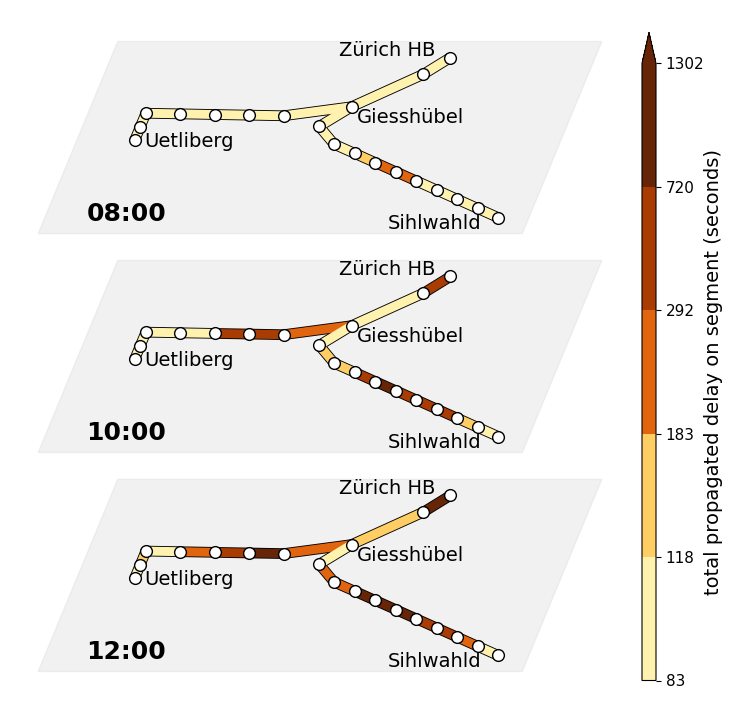

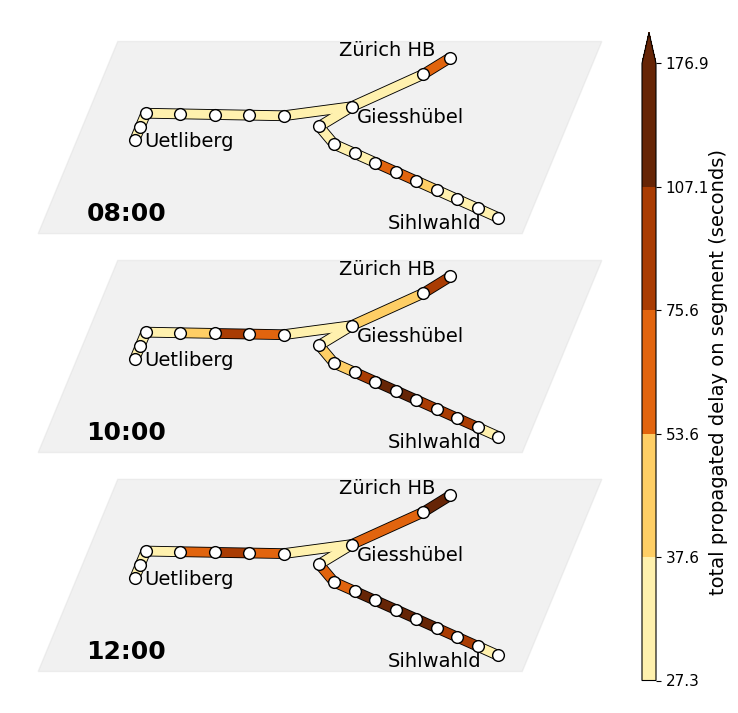

In [ ]:
### FINAL
ystandardlower = 0.4
ystandardlower2 = 0.6
ystandardupper = -0.35
xstandardupper = 0.7
xstandardlower2 = 0
stationposdelta = {
    "Zürich HB SZU": (-1.5,-1*ystandardlower),
    'Selnau': (+0.7,-ystandardlower),
    'Giesshübel': (+1.4,-7*ystandardlower),
    'Saalsporthalle': (-1.2+xstandardlower2,-ystandardlower2),
    'Brunau': (-0.75+xstandardlower2,-ystandardlower2),
    'Manegg': (-0.8+xstandardlower2,-ystandardlower2),
    'Leimbach': (-0.9+xstandardlower2,-ystandardlower2-0.05),
    'Sood-Oberleimbach': (-1.55+xstandardlower2,-ystandardlower2),
    'Adliswil': (-0.8+xstandardlower2,-ystandardlower2),
    'Sihlau': (-0.7+xstandardlower2,-ystandardlower2),
    'Wildpark-Hüfli': (-1.25+xstandardlower2,-ystandardlower2),
    'Langnau-Gattikon': (-1.4+xstandardlower2,-ystandardlower2),
    'Sihlwahld': (-1.5+xstandardlower2,-3.5*ystandardlower2),
    'Binz': (xstandardupper-0.35,-ystandardupper+0.05),
    'Friesenberg': (xstandardupper,-ystandardupper),
    'Schweighof': (xstandardupper-0.05,-ystandardupper),
    'Triemli': (xstandardupper-0.25,-ystandardupper),
    'Uitikon': (-1.3,-ystandardupper),
    'Waldegg': (-1.3,-ystandardupper),
    'Ringlikon': (-0.8,-0.3),
    'Uetliberg': (1.3,-1.5),
    }
generate_network_plot_final(results_mean, node_station_pos,
                      newnewpositions,
                      stations_data,
                      station_to_node,
                      stationposdelta,
                      stationposrot,
                      ytilt = 1,
                      xtilt = 1,
                      rotangledeg = -5,
                      save_path="stacked_heatmap_a.pdf")
